# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 1: Ukrainian High-Voltage Network (18 points)

In this task, you will perform some network analysis on data about the Ukrainian high-voltage electricity transmission network extracted from OpenStreetMap data via the repository [Prebuilt Electricity Network for PyPSA-Eur based on OpenStreetMap Data](https://zenodo.org/records/18619025). The two files below contain data on the lines and transformers of the Ukrainian high-voltage network.

In [1]:
url_lines = "https://tubcloud.tu-berlin.de/s/QzaGiezn8SR6TX5/download/ukraine_lines.geojson"

url_transformers = "https://tubcloud.tu-berlin.de/s/oPLbXd897XBSJy4/download/ukraine_transformers.geojson"

In [25]:
import cartopy
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd

**a)** Read the lines and transformers into two separate `geopandas.GeoDataFrame` objects called `lines` and `transformers`. Set the first columns as the index. **(2 points)**

In [7]:
# YOUR CODE HERE
lines = gpd.read_file(url_lines)
transformers = gpd.read_file(url_transformers)
lines = lines.set_index(lines.columns[0])
transformers = transformers.set_index(transformers.columns[0])
lines, transformers


(                                                      bus0  \
 line_id                                                      
 merged_relation/7484512-220+1            way/475267318-220   
 merged_way/107807065-750+1               way/142155240-750   
 merged_way/1127485812-220+3          relation/10047997-220   
 merged_way/1130860076-400+1    virtual_way/166838340:0-400   
 merged_way/129089049-330+4            relation/9354587-330   
 ...                                                    ...   
 way/803315051-220              virtual_way/226623706:1-220   
 way/804784454-330                     relation/9241264-330   
 way/84841455-330                         way/912367407-330   
 way/926795298-330              virtual_way/304211653:0-330   
 way/926795299-330              virtual_way/304211653:0-330   
 
                                                       bus1  voltage  i_nom  \
 line_id                                                                      
 merged_relation/7484

In [8]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(lines, gpd.GeoDataFrame)

In [9]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(transformers, gpd.GeoDataFrame)

**b)** Plot the transmission lines on a map, such that the colors of the line indicate the voltage levels of the lines (in kV) and the width of the lines is proportional to the rated capacity (`s_nom`, in MW). Use the Mollweide projection. The figure should have a size of 12 by 9 inches, and a horizontal colorbar for the colors. A legend for the line width is not required. Add coastlines and country borders for orientation. **(3 points)**

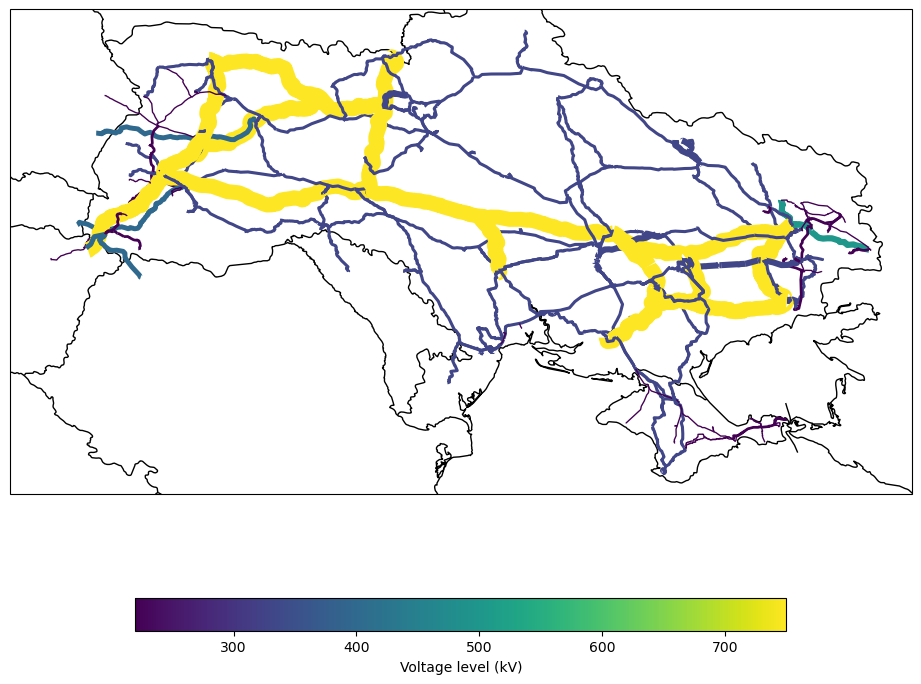

In [46]:
# YOUR CODE HERE

crs = ccrs.Mollweide()
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=crs)
line_widths = lines["s_nom"] / 500.0
lines.to_crs(crs).plot(ax=ax, column = 'voltage', cmap='viridis', linewidth = line_widths, legend = True, legend_kwds={
        "orientation": "horizontal",
        "label": "Voltage level (kV)",
        "shrink": 0.7,
    })
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)



**c)** Identify the number of lines by voltage level. Return your answer as a `pandas.Series` with the voltage levels as index (in kV) and the counts as values in ascending order. **(2 points)**

In [47]:
# YOUR CODE HERE
voltage_counts = lines.groupby("voltage").size().sort_values(ascending=True)
voltage_counts

voltage
500      4
400      5
750     18
220    106
330    255
dtype: int64

In [48]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**d)** Create a single joined `networkx.Graph` from the lines and transformer data using the function `networkx.from_pandas_edgelist()` and [`networkx.compose()`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.operators.binary.compose.html). As attribute include the capacity `s_nom`. Return the `networkx.Graph` object. **(2 points)**

In [29]:
# # YOUR CODE HERE
network_graph = nx.compose(nx.from_pandas_edgelist(lines, source='bus0', target='bus1', edge_attr='s_nom'), nx.from_pandas_edgelist(transformers, source='bus0', target='bus1', edge_attr='s_nom'))
network_graph

In [30]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, nx.Graph)

In [31]:
### AUTOGRADING CELL - DO NOT TOUCH!

**e)** Compute the directed incidence matrix of the network and return it as a `numpy.array`. **(2 points)**

In [49]:
# YOUR CODE HERE
incidence_matrix = nx.incidence_matrix(network_graph, oriented=True).toarray()
incidence_matrix

array([[-1., -1., -1., ...,  0.,  0.,  0.],
       [ 1.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  1.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(297, 384))

In [50]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, np.ndarray)

**f)** Provide the number of linearly independent cycles in the network. Return the result as an integer. **(2 points)**

In [36]:
# YOUR CODE HERE
cycles = nx.cycle_basis(network_graph)
number_of_cycles = len(cycles)
number_of_cycles
#linearly independent cycles

88

In [37]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, int)

**g)** The *minimal cycle basis* of a network is the set of cycles that form a basis for the cycle space of the network, such that the total number edges involved is minimised. Compute the minimal cycle basis by looking for the right function in the `networkx` documentation. Then compute the average number of edges per cycle. Return the result as a float. **(3 points)**

In [38]:
# YOUR CODE HERE
minimum_cycle_basis = nx.minimum_cycle_basis(network_graph, weight=None)
minimum_cycle_basis
average_number_of_edges_per_cycle = sum(len(cycle) for cycle in minimum_cycle_basis) / len(minimum_cycle_basis)
average_number_of_edges_per_cycle

6.2272727272727275

In [39]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [40]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**h)** Identify the bus with the highest degree. Return its name as a string. **(2 points)**

In [44]:
# YOUR CODE HERE
degrees = dict(network_graph.degree())
highest_bus = max(degrees, key=degrees.get)
highest_bus

'way/142155240-330'

In [45]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, str)